In [1]:
from src.carregador_dados import CarregadorDados

carregador = CarregadorDados("dataset/")

experimentos = carregador.carregar_participante(
    "USAB-JPA-01"
)

baseline = experimentos["baseline"]
facil = experimentos["stage_1"]
dificil = experimentos["stage_8"]

print(baseline.sinal)
print(baseline.taxa_amostragem)
print(baseline.duracao)

[-529   71 1346 ... -204 -220 -231]
130
312.2153846153846


In [2]:
from src.processador_ecg import ProcessadorECG

processador_baseline = ProcessadorECG(baseline)
processador_facil = ProcessadorECG(facil)
processador_dificil = ProcessadorECG(dificil)

resultado_baseline = processador_baseline.processar()
resultado_facil = processador_facil.processar()
resultado_dificil = processador_dificil.processar()

In [3]:
print("Baseline")
print(f"SNR: {resultado_baseline['snr_db']:.2f} dB")
print(f"Picos R: {resultado_baseline['numero_picos_r']}")
print(f"Intervalos RR: {resultado_baseline['numero_rr']}")
print(f"RR removidos: {resultado_baseline['numero_rr_removidos']}")
print(
    f"RR removidos (%): "
    f"{resultado_baseline['percentual_rr_removidos']:.2f}%"
)

print("\nStage 1 - Fácil")
print(f"SNR: {resultado_facil['snr_db']:.2f} dB")
print(f"Picos R: {resultado_facil['numero_picos_r']}")
print(f"Intervalos RR: {resultado_facil['numero_rr']}")
print(f"RR removidos: {resultado_facil['numero_rr_removidos']}")
print(
    f"RR removidos (%): "
    f"{resultado_facil['percentual_rr_removidos']:.2f}%"
)

print("\nStage 8 - Difícil")
print(f"SNR: {resultado_dificil['snr_db']:.2f} dB")
print(f"Picos R: {resultado_dificil['numero_picos_r']}")
print(f"Intervalos RR: {resultado_dificil['numero_rr']}")
print(f"RR removidos: {resultado_dificil['numero_rr_removidos']}")
print(
    f"RR removidos (%): "
    f"{resultado_dificil['percentual_rr_removidos']:.2f}%"
)

Baseline
SNR: -7.32 dB
Picos R: 483
Intervalos RR: 482
RR removidos: 0
RR removidos (%): 0.00%

Stage 1 - Fácil
SNR: -1.35 dB
Picos R: 533
Intervalos RR: 532
RR removidos: 0
RR removidos (%): 0.00%

Stage 8 - Difícil
SNR: 2.51 dB
Picos R: 1819
Intervalos RR: 1818
RR removidos: 0
RR removidos (%): 0.00%


In [4]:
from src.analisador_hrv import AnalisadorHRV

analisador_baseline = AnalisadorHRV(
    resultado_baseline["intervalos_nn"]
)

analisador_facil = AnalisadorHRV(
    resultado_facil["intervalos_nn"]
)

analisador_dificil = AnalisadorHRV(
    resultado_dificil["intervalos_nn"]
)

hrv_baseline = analisador_baseline.calcular_hrv()
hrv_facil = analisador_facil.calcular_hrv()
hrv_dificil = analisador_dificil.calcular_hrv()

In [5]:
print("Baseline")
for metrica, valor in hrv_baseline.items():
    print(f"{metrica}: {valor:.2f}")

print("\nStage 1 - Fácil")
for metrica, valor in hrv_facil.items():
    print(f"{metrica}: {valor:.2f}")

print("\nStage 8 - Difícil")
for metrica, valor in hrv_dificil.items():
    print(f"{metrica}: {valor:.2f}")

Baseline
hr_bpm: 92.92
rmssd_ms: 18.60
sdnn_ms: 38.08
mf_ms2: 695.42
hf_ms2: 119.74
mf_medio_janelas_ms2: 505.16
mf_p95_ms2: 2639.52
mfp95_mean: 5.23

Stage 1 - Fácil
hr_bpm: 92.67
rmssd_ms: 19.85
sdnn_ms: 33.20
mf_ms2: 366.44
hf_ms2: 106.30
mf_medio_janelas_ms2: 294.08
mf_p95_ms2: 586.42
mfp95_mean: 1.99

Stage 8 - Difícil
hr_bpm: 93.67
rmssd_ms: 20.62
sdnn_ms: 39.67
mf_ms2: 525.24
hf_ms2: 160.85
mf_medio_janelas_ms2: 439.27
mf_p95_ms2: 1389.85
mfp95_mean: 3.16


In [6]:
import pandas as pd

tabela_hrv = pd.DataFrame(
    [
        {
            "condicao": "Baseline",
            **hrv_baseline,
        },
        {
            "condicao": "Stage 1 - Fácil",
            **hrv_facil,
        },
        {
            "condicao": "Stage 8 - Difícil",
            **hrv_dificil,
        },
    ]
)

tabela_hrv

,condicao,hr_bpm,rmssd_ms,sdnn_ms,mf_ms2,hf_ms2,mf_medio_janelas_ms2,mf_p95_ms2,mfp95_mean
0,Baseline,92.919107,18.599093,38.076576,695.417520,119.740656,505.164181,2639.516248,5.225066
1,Stage 1 - Fácil,92.674647,19.847422,33.196731,366.441185,106.303156,294.077552,586.424847,1.994116
2,Stage 8 - Difícil,93.667391,20.619001,39.665394,525.239270,160.850224,439.272362,1389.847181,3.163976


In [7]:
from src.plot_individual import plotar_participante

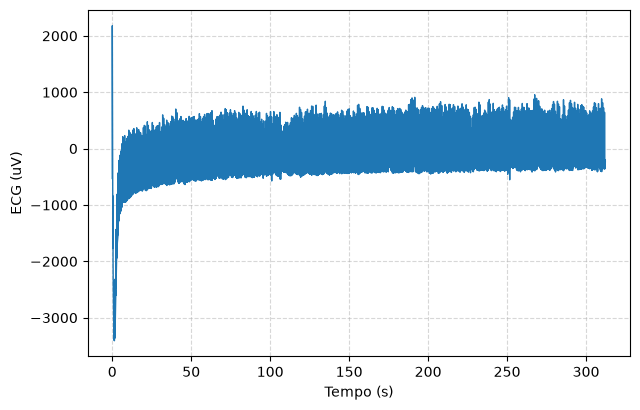

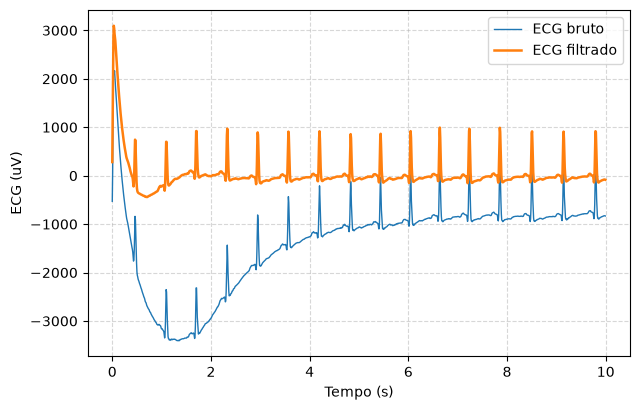

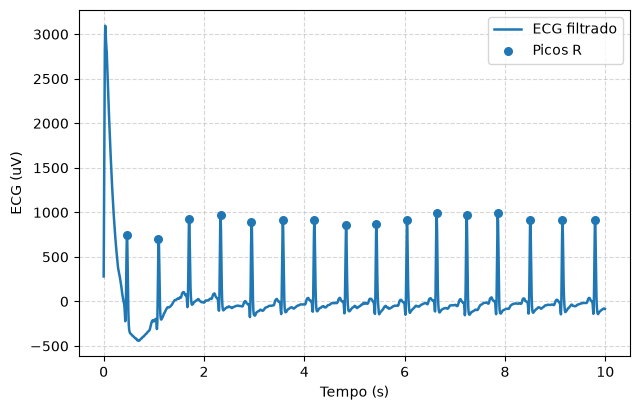

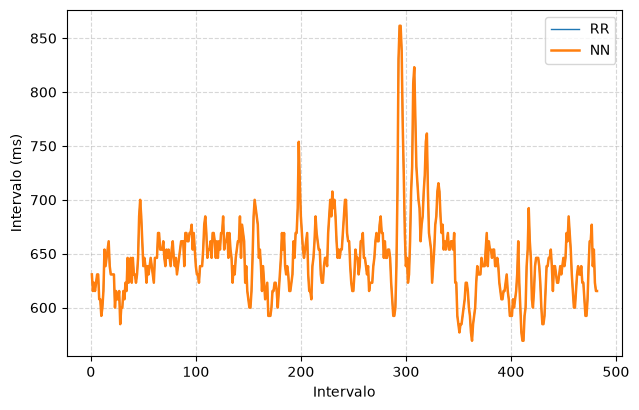

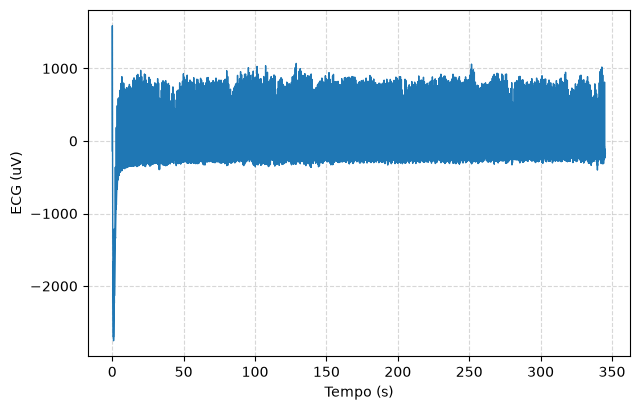

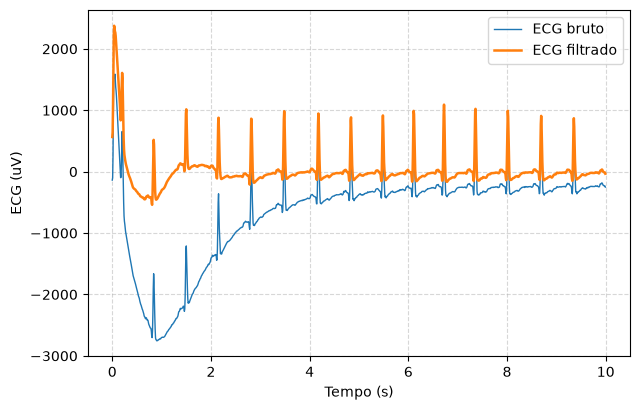

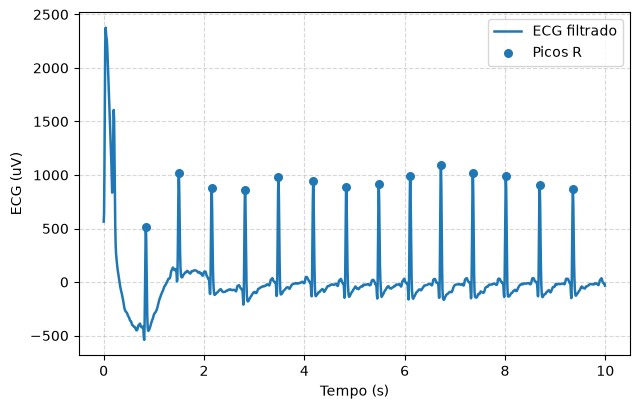

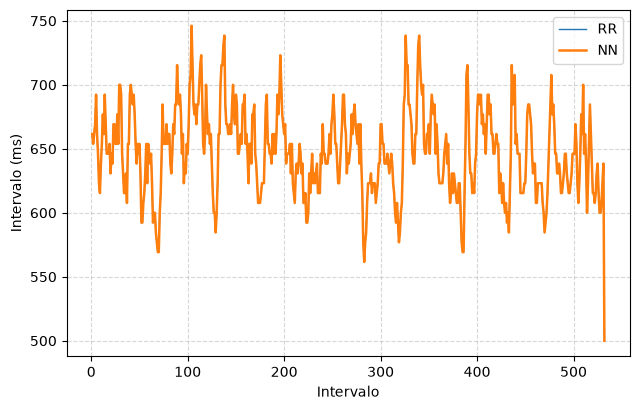

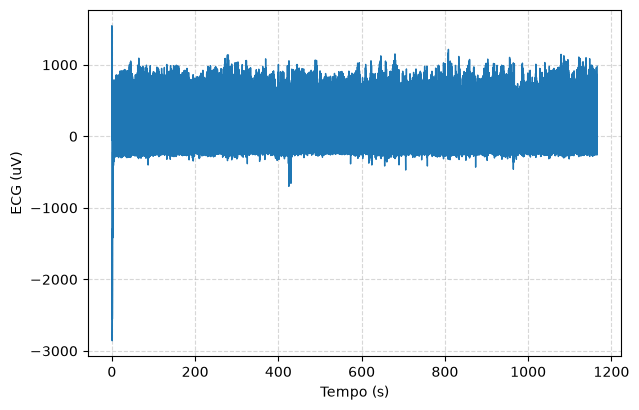

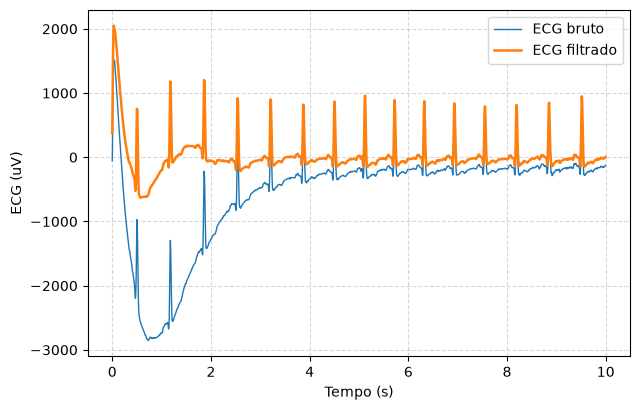

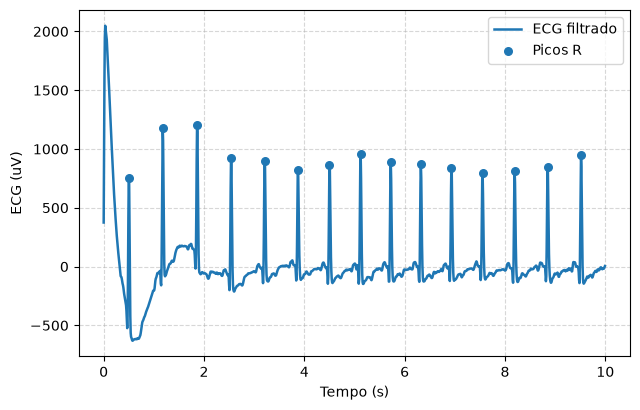

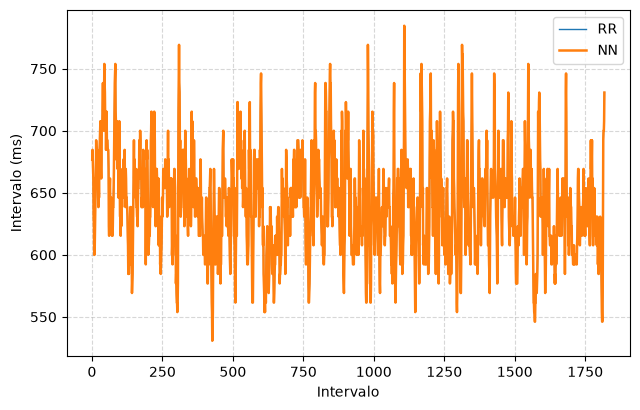

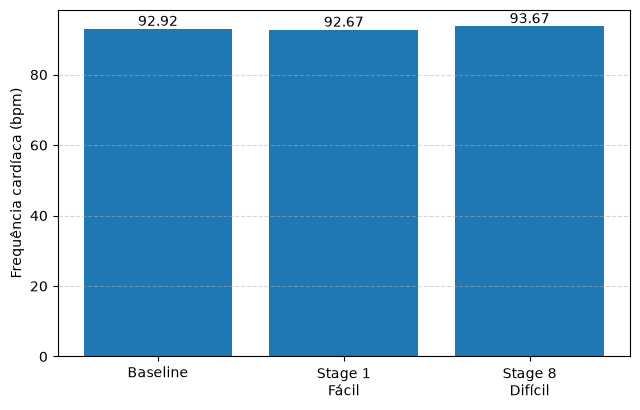

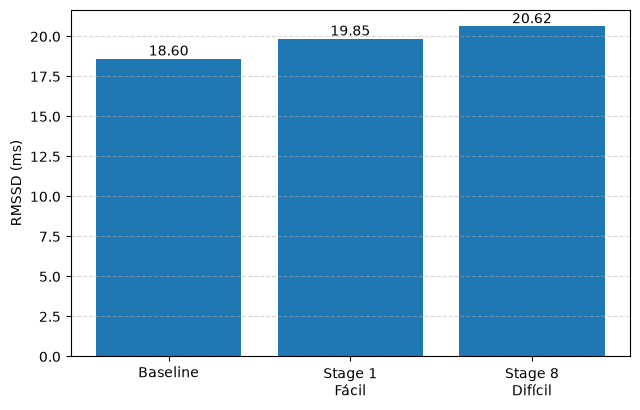

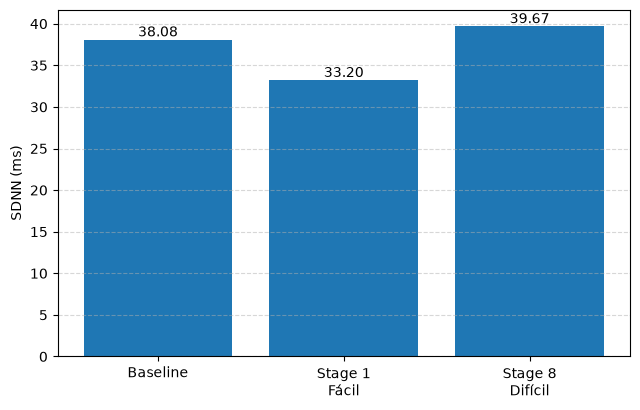

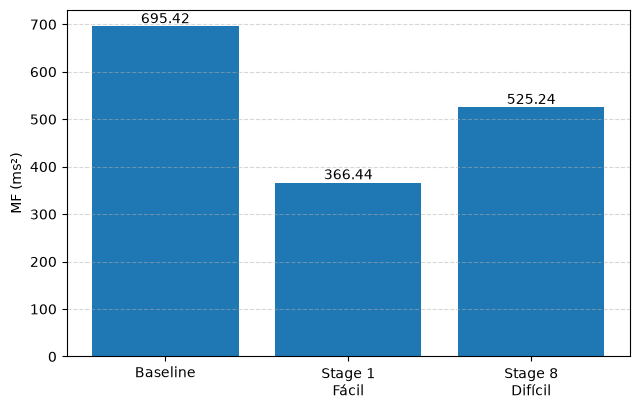

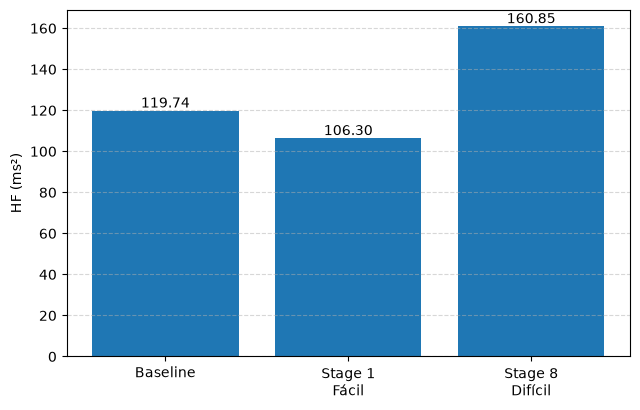

In [8]:
diretorio_figuras = "./dataset/brunolima"

plotar_participante(
    baseline=baseline,
    facil=facil,
    dificil=dificil,

    resultado_baseline=resultado_baseline,
    resultado_facil=resultado_facil,
    resultado_dificil=resultado_dificil,

    hrv_baseline=hrv_baseline,
    hrv_facil=hrv_facil,
    hrv_dificil=hrv_dificil,

    diretorio_saida=diretorio_figuras,
)


In [9]:
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.signal import welch


def calcular_mfp95(intervalos_nn):
    """
    Calcula a métrica MF_P95/Mean.

    Procedimento:
        1. Interpola os intervalos NN em 4 Hz
        2. Divide o sinal em janelas de 60 s
        3. Utiliza avanço de 10 s
        4. Calcula a PSD de Welch em cada janela
        5. Calcula a potência MF entre 0,07 e 0,15 Hz
        6. Calcula P95(MF)
        7. Calcula MF_P95/Mean

    Entrada:
        intervalos_nn: intervalos NN em milissegundos

    Retorna:
        MF médio
        percentil 95 da MF
        MF_P95/Mean
        valores de MF de cada janela
    """

    nn = np.asarray(intervalos_nn, dtype=float)

    # --------------------------------------------------------
    # 1. Tempo acumulado dos intervalos NN
    # --------------------------------------------------------

    tempo_nn = np.cumsum(nn) / 1000.0
    tempo_nn = tempo_nn - tempo_nn[0]

    # --------------------------------------------------------
    # 2. Interpolação em 4 Hz
    # --------------------------------------------------------

    fs = 4.0

    interpolador = CubicSpline(
        tempo_nn,
        nn,
    )

    tempo_uniforme = np.arange(
        tempo_nn[0],
        tempo_nn[-1],
        1.0 / fs,
    )

    nn_interpolado = interpolador(
        tempo_uniforme
    )

    # --------------------------------------------------------
    # 3. Configuração das janelas
    # --------------------------------------------------------

    duracao_janela = 60
    passo = 10

    amostras_janela = int(
        duracao_janela * fs
    )

    amostras_passo = int(
        passo * fs
    )

    valores_mf = []

    # --------------------------------------------------------
    # 4. Percorrer as janelas
    # --------------------------------------------------------

    for inicio in range(
        0,
        len(nn_interpolado) - amostras_janela + 1,
        amostras_passo,
    ):

        fim = inicio + amostras_janela

        janela = nn_interpolado[
            inicio:fim
        ]

        # Remover média da janela
        janela = janela - np.mean(janela)

        # ----------------------------------------------------
        # 5. PSD de Welch
        # ----------------------------------------------------

        frequencias, psd = welch(
            janela,
            fs=fs,
        )

        # ----------------------------------------------------
        # 6. Banda MF: 0,07 - 0,15 Hz
        # ----------------------------------------------------

        mascara_mf = (
            (frequencias >= 0.07)
            & (frequencias < 0.15)
        )

        mf = np.trapezoid(
            psd[mascara_mf],
            frequencias[mascara_mf],
        )

        valores_mf.append(mf)

    valores_mf = np.asarray(
        valores_mf
    )

    if len(valores_mf) == 0:
        raise ValueError(
            "Não existem dados suficientes para uma janela de 60 s."
        )

    # --------------------------------------------------------
    # 7. MF médio
    # --------------------------------------------------------

    mf_medio = np.mean(
        valores_mf
    )

    # --------------------------------------------------------
    # 8. Percentil 95
    # --------------------------------------------------------

    mf_p95 = np.percentile(
        valores_mf,
        95,
    )

    # --------------------------------------------------------
    # 9. MF_P95/Mean
    # --------------------------------------------------------

    mfp95_mean = (
        mf_p95 / mf_medio
    )

    return {
        "mf_medio_ms2": float(mf_medio),
        "mf_p95_ms2": float(mf_p95),
        "mfp95_mean": float(mfp95_mean),
        "mf_janelas": valores_mf,
    }
    

In [10]:
print("1 - iniciando")

print(
    "NN baseline:",
    len(resultado_baseline["intervalos_nn"])
)

print(
    "NN fácil:",
    len(resultado_facil["intervalos_nn"])
)

print(
    "NN difícil:",
    len(resultado_dificil["intervalos_nn"])
)

print("2 - calculando baseline")

mfp95_baseline = calcular_mfp95(
    resultado_baseline["intervalos_nn"]
)

print("3 - baseline concluído")
print(mfp95_baseline)

print("4 - calculando fácil")

mfp95_facil = calcular_mfp95(
    resultado_facil["intervalos_nn"]
)

print("5 - fácil concluído")
print(mfp95_facil)

print("6 - calculando difícil")

mfp95_dificil = calcular_mfp95(
    resultado_dificil["intervalos_nn"]
)

print("7 - difícil concluído")
print(mfp95_dificil)


1 - iniciando
NN baseline: 482
NN fácil: 532
NN difícil: 1818
2 - calculando baseline
3 - baseline concluído
{'mf_medio_ms2': 505.1641808608391, 'mf_p95_ms2': 2639.5162482999203, 'mfp95_mean': 5.225066123655044, 'mf_janelas': array([  79.65584334,   43.30362253,   20.05726644,   47.36344143,
         58.99850259,  107.73285345,  296.09096651,  328.54910902,
        208.14211091,  259.92579312,  328.94353436,  335.48856588,
        334.12827145,  258.76688473,  285.81882135, 1553.11165869,
       3477.79730261, 3001.6511115 , 1162.53022946,  389.74410472,
        184.51865539,   75.46645017,   29.7863573 ,   61.13760099,
         90.43198822,  115.1276562 ])}
4 - calculando fácil
5 - fácil concluído
{'mf_medio_ms2': 294.07755219909984, 'mf_p95_ms2': 586.4248471102171, 'mfp95_mean': 1.9941163231431853, 'mf_janelas': array([412.22526197, 429.82879997, 436.03747167, 377.72811876,
       272.36427957, 373.30847839, 422.62743755, 206.81512978,
       181.37038778, 234.65303734, 144.27981997,

/var/folders/9y/d81gj55s5v17_kk02y3qg6dr0000gn/T/ipykernel_5273/85887463.py:99: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 240, using nperseg = 240
  frequencias, psd = welch(


In [11]:
mfp95_baseline = calcular_mfp95(
    resultado_baseline["intervalos_nn"]
)

mfp95_facil = calcular_mfp95(
    resultado_facil["intervalos_nn"]
)

mfp95_dificil = calcular_mfp95(
    resultado_dificil["intervalos_nn"]
)

print("MF P95/Mean")
print(f"Baseline: {mfp95_baseline['mfp95_mean']:.3f}")
print(f"Stage 1 - Fácil: {mfp95_facil['mfp95_mean']:.3f}")
print(f"Stage 8 - Difícil: {mfp95_dificil['mfp95_mean']:.3f}")

MF P95/Mean
Baseline: 5.225
Stage 1 - Fácil: 1.994
Stage 8 - Difícil: 3.164


/var/folders/9y/d81gj55s5v17_kk02y3qg6dr0000gn/T/ipykernel_5273/85887463.py:99: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 240, using nperseg = 240
  frequencias, psd = welch(


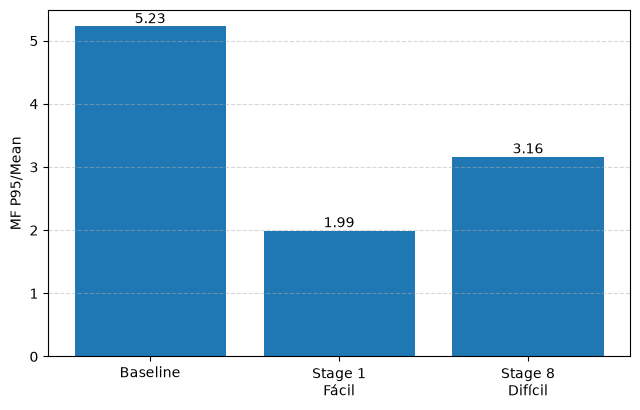

In [12]:
import matplotlib.pyplot as plt

condicoes = [
    "Baseline",
    "Stage 1\nFácil",
    "Stage 8\nDifícil",
]

valores = [
    mfp95_baseline["mfp95_mean"],
    mfp95_facil["mfp95_mean"],
    mfp95_dificil["mfp95_mean"],
]

fig, ax = plt.subplots(figsize=(6.5, 4.2))

barras = ax.bar(
    condicoes,
    valores,
)

ax.set_ylabel("MF P95/Mean")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5,
)

for barra, valor in zip(barras, valores):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{valor:.2f}",
        ha="center",
        va="bottom",
    )

fig.tight_layout()
plt.show()

In [13]:
from src.analisador_sus import AnalisadorSUS

analisador_sus = AnalisadorSUS(
    "dataset/"
)

sus = analisador_sus.analisar_participante(
    "USAB-JPA-01"
)

print(sus)

[{'participante': 'USAB-JPA-01', 'condicao': 'stage_1', 'sus_score': 95.0}, {'participante': 'USAB-JPA-01', 'condicao': 'stage_8', 'sus_score': 50.0}]


In [14]:
import pandas as pd

from src.analisador_correlacao import AnalisadorCorrelacao


df_hrv = pd.DataFrame([
    {
        "participante": "USAB-JPA-01",
        "condicao": "stage_1",
        **hrv_facil,
    },
    {
        "participante": "USAB-JPA-01",
        "condicao": "stage_8",
        **hrv_dificil,
    },
])


df_sus = pd.DataFrame(
    sus
)


analisador_correlacao = AnalisadorCorrelacao()

variacoes = (
    analisador_correlacao.calcular_variacoes(
        df_hrv,
        df_sus,
    )
)


print("HRV:")
print(df_hrv.to_string(index=False))

print("\nSUS:")
print(df_sus.to_string(index=False))

print("\nVariações Stage 8 - Stage 1:")
print(variacoes.to_string(index=False))

HRV:
participante condicao    hr_bpm  rmssd_ms   sdnn_ms     mf_ms2     hf_ms2  mf_medio_janelas_ms2  mf_p95_ms2  mfp95_mean
 USAB-JPA-01  stage_1 92.674647 19.847422 33.196731 366.441185 106.303156            294.077552  586.424847    1.994116
 USAB-JPA-01  stage_8 93.667391 20.619001 39.665394 525.239270 160.850224            439.272362 1389.847181    3.163976

SUS:
participante condicao  sus_score
 USAB-JPA-01  stage_1       95.0
 USAB-JPA-01  stage_8       50.0

Variações Stage 8 - Stage 1:
participante  sus_stage_1  sus_stage_8  delta_sus  hr_bpm_stage_1  hr_bpm_stage_8  delta_hr_bpm  rmssd_ms_stage_1  rmssd_ms_stage_8  delta_rmssd_ms  sdnn_ms_stage_1  sdnn_ms_stage_8  delta_sdnn_ms  mf_ms2_stage_1  mf_ms2_stage_8  delta_mf_ms2  hf_ms2_stage_1  hf_ms2_stage_8  delta_hf_ms2
 USAB-JPA-01         95.0         50.0      -45.0       92.674647       93.667391      0.992744         19.847422         20.619001        0.771579        33.196731        39.665394       6.468664      366.44118